# Shazam Robustness — Results Analysis

Reads `results/shazam_eval.csv` produced by `evaluate_shazam.py` and produces:

- Overall outcome breakdown (correct / wrong-ID / no-ID)
- Top-1 accuracy and false-positive rate across SNR, per noise type
- Per-genre accuracy (bar + heatmap)
- Genre × SNR heatmaps for each noise type
- Identification latency distribution and by condition
- Score / confidence distributions by outcome
- Genre confusion analysis (when wrong, what genre did it pick?)

**Convention used throughout:**
- `correct == 'yes'` &rarr; **TRUE POSITIVE** (matched the right song)
- `identified == 'yes' & correct == 'no'` &rarr; **FALSE POSITIVE** (confidently picked a wrong song)
- `identified == 'no'` &rarr; **REJECT** (matcher returned None; failed safely)

In [26]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CSV_PATH = Path("results/shazam_eval.csv")
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"{CSV_PATH} not found. Run evaluate_shazam.py first."
    )

df = pd.read_csv(CSV_PATH)

# Outcome label per row.
def outcome(row):
    if row["identified"] == "no":
        return "reject"
    return "correct" if row["correct"] == "yes" else "false_positive"

df["outcome"] = df.apply(outcome, axis=1)
df["snr_db"] = df["snr_db"].astype(int)

# Genre of the wrongly-picked match (when applicable). GTZAN convention: 'genre.NNNNN.wav'.
df["top_match_genre"] = (
    df["top_match_name"].fillna("").str.split(".").str[0].replace("", np.nan)
)

print(f"Loaded {len(df):,} rows")
df.head()

Loaded 8,991 rows


,noise_type,snr_db,genre,filename,ground_truth_name,snippet_start_s,snippet_seconds,identified,correct,elapsed_s,top_match_name,score,confidence,query_fingerprints,outcome,top_match_genre
0,crowd_noise,0,blues,blues.00000.wav,blues.00000.wav,15.669,10.0,yes,yes,4.7302,blues.00000.wav,446.0,17.74,2514.0,correct,blues
1,crowd_noise,0,blues,blues.00001.wav,blues.00001.wav,5.978,10.0,yes,yes,2.8672,blues.00001.wav,714.0,28.12,2539.0,correct,blues
2,crowd_noise,0,blues,blues.00002.wav,blues.00002.wav,11.741,10.0,yes,yes,3.1303,blues.00002.wav,912.0,32.56,2801.0,correct,blues
3,crowd_noise,0,blues,blues.00003.wav,blues.00003.wav,5.727,10.0,yes,yes,2.6221,blues.00003.wav,516.0,22.74,2269.0,correct,blues
4,crowd_noise,0,blues,blues.00004.wav,blues.00004.wav,1.879,10.0,yes,yes,0.5048,blues.00004.wav,465.0,20.30,2291.0,correct,blues


## 1. Coverage sanity check
How many rows per (noise_type, snr) cell? Should be ~999 if the full sweep ran.


In [27]:
coverage = df.pivot_table(
    index="noise_type", columns="snr_db", values="filename", aggfunc="count"
).fillna(0).astype(int)
coverage

snr_db,0,10,20
noise_type,,,
crowd_noise,999,999,999
street_noise,999,999,999
white_noise,999,999,999


## 2. Overall outcome breakdown
Three-way split across the entire run.


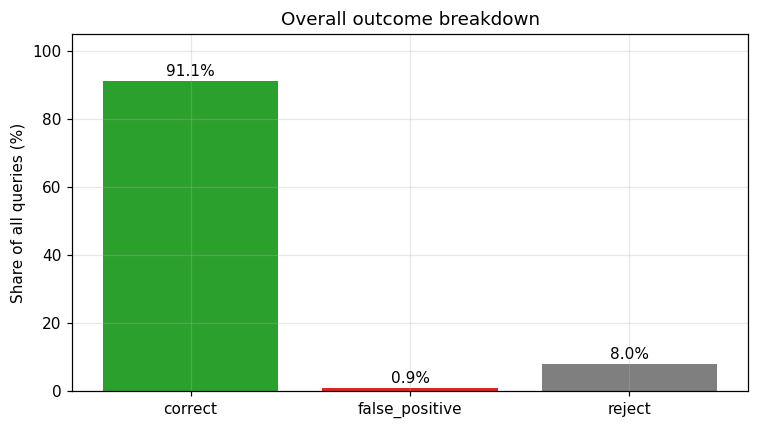

outcome
correct           91.15
false_positive     0.89
reject             7.96
Name: proportion, dtype: float64


In [28]:
overall = df["outcome"].value_counts(normalize=True).reindex(
    ["correct", "false_positive", "reject"]
).fillna(0) * 100

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2ca02c", "#d62728", "#7f7f7f"]
bars = ax.bar(overall.index, overall.values, color=colors)
for b, v in zip(bars, overall.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.1f}%",
            ha="center", va="bottom")
ax.set_ylabel("Share of all queries (%)")
ax.set_title("Overall outcome breakdown")
ax.set_ylim(0, max(overall.values) * 1.15)
plt.tight_layout()
plt.show()

print(overall.round(2))

### 2a. Outcome breakdown per SNR level
Same three-way split, but separated by SNR (averaged across all noise types and genres).

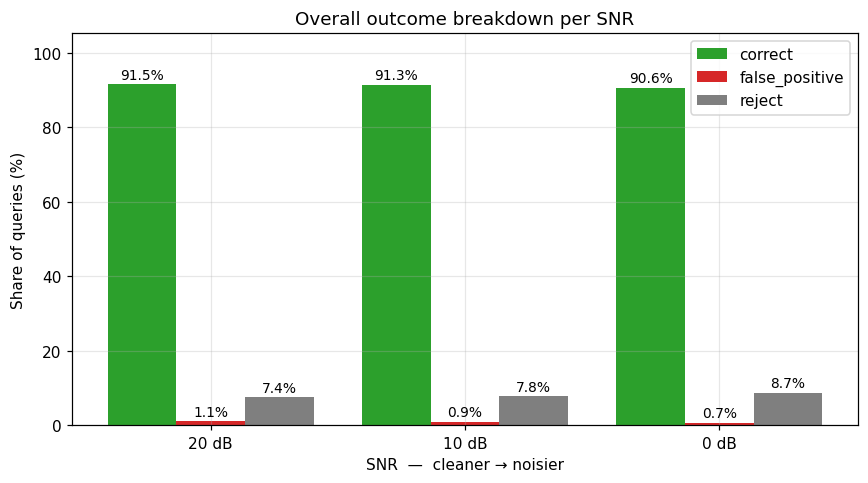

outcome,correct,false_positive,reject
snr_db,,,
20,91.49,1.07,7.44
10,91.32,0.90,7.77
0,90.62,0.70,8.68


In [29]:
snr_levels = sorted(df["snr_db"].unique(), reverse=True)
outcomes = ["correct", "false_positive", "reject"]
colors_map = {"correct": "#2ca02c", "false_positive": "#d62728", "reject": "#7f7f7f"}

by_snr = (
    df.groupby("snr_db")["outcome"]
      .value_counts(normalize=True)
      .unstack(fill_value=0)
      .reindex(columns=outcomes, fill_value=0) * 100
).reindex(snr_levels)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(snr_levels))
width = 0.27
for i, oc in enumerate(outcomes):
    bars = ax.bar(x + (i - 1) * width, by_snr[oc].values, width,
                  label=oc, color=colors_map[oc])
    for b, v in zip(bars, by_snr[oc].values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.7,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"{s} dB" for s in snr_levels])
ax.set_xlabel("SNR  —  cleaner → noisier")
ax.set_ylabel("Share of queries (%)")
ax.set_title("Overall outcome breakdown per SNR")
ax.set_ylim(0, max(by_snr.values.max() * 1.15, 10))
ax.legend()
plt.tight_layout()
plt.show()

by_snr.round(2)

## 3. Performance across SNR
Top-1 accuracy and false-positive rate as SNR drops, broken out by noise type.

/var/folders/wl/l56wm40d1r3d017gmh_0qgbw0000gn/T/ipykernel_8801/759881802.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = df.groupby(["noise_type", "snr_db"]).apply(


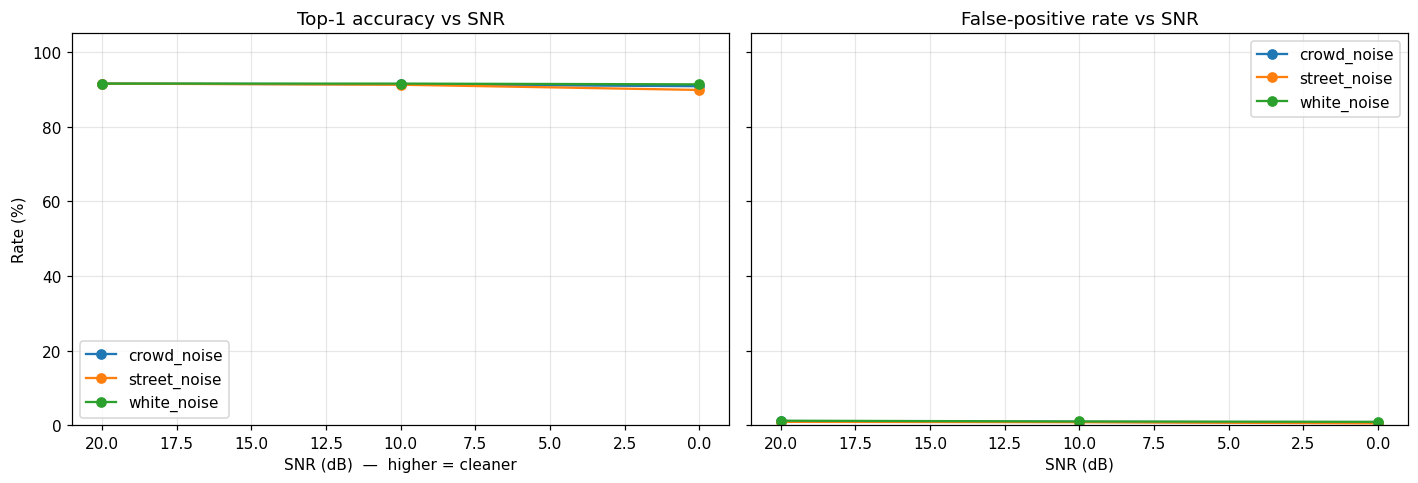

,noise_type,snr_db,accuracy,false_positive,reject,n
0,crowd_noise,0,90.79,0.7,8.51,999.0
1,crowd_noise,10,91.29,0.9,7.81,999.0
2,crowd_noise,20,91.49,1.1,7.41,999.0
3,street_noise,0,89.79,0.5,9.71,999.0
4,street_noise,10,91.19,0.8,8.01,999.0
5,street_noise,20,91.49,0.9,7.61,999.0
6,white_noise,0,91.29,0.9,7.81,999.0
7,white_noise,10,91.49,1.0,7.51,999.0
8,white_noise,20,91.49,1.2,7.31,999.0


In [30]:
def rate(g, label):
    return (g["outcome"] == label).mean() * 100

agg = df.groupby(["noise_type", "snr_db"]).apply(
    lambda g: pd.Series({
        "accuracy": rate(g, "correct"),
        "false_positive": rate(g, "false_positive"),
        "reject": rate(g, "reject"),
        "n": len(g),
    })
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for noise_type, sub in agg.groupby("noise_type"):
    sub = sub.sort_values("snr_db")
    axes[0].plot(sub["snr_db"], sub["accuracy"], marker="o", label=noise_type)
    axes[1].plot(sub["snr_db"], sub["false_positive"], marker="o", label=noise_type)

axes[0].set_title("Top-1 accuracy vs SNR")
axes[0].set_xlabel("SNR (dB)  \u2014  higher = cleaner")
axes[0].set_ylabel("Rate (%)")
axes[0].invert_xaxis()  # noise gets worse moving right
axes[0].legend()

axes[1].set_title("False-positive rate vs SNR")
axes[1].set_xlabel("SNR (dB)")
axes[1].invert_xaxis()
axes[1].legend()

for ax in axes:
    ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

agg.round(2)

### 3a. Stacked outcome composition per condition
Visualises the trade between accuracy, false positives, and rejects as SNR drops.

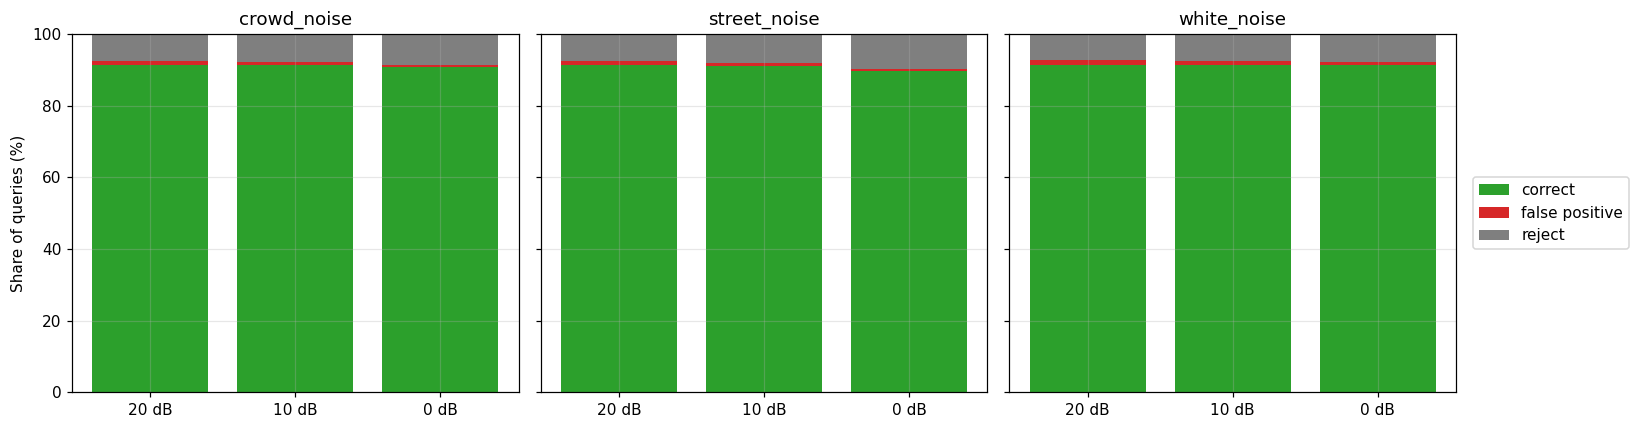

In [31]:
noise_types = sorted(df["noise_type"].unique())
snrs = sorted(df["snr_db"].unique(), reverse=True)

fig, axes = plt.subplots(1, len(noise_types), figsize=(5 * len(noise_types), 4),
                          sharey=True)
if len(noise_types) == 1:
    axes = [axes]

for ax, nt in zip(axes, noise_types):
    sub = agg[agg["noise_type"] == nt].set_index("snr_db").reindex(snrs)
    x = np.arange(len(snrs))
    ax.bar(x, sub["accuracy"], label="correct", color="#2ca02c")
    ax.bar(x, sub["false_positive"], bottom=sub["accuracy"],
           label="false positive", color="#d62728")
    ax.bar(x, sub["reject"], bottom=sub["accuracy"] + sub["false_positive"],
           label="reject", color="#7f7f7f")
    ax.set_title(nt)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{s} dB" for s in snrs])
    ax.set_ylim(0, 100)
axes[0].set_ylabel("Share of queries (%)")
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

## 4. Per-genre accuracy
Some genres (e.g. classical) have more transient/percussive content than others. This shows whether the fingerprinter favours certain genres.

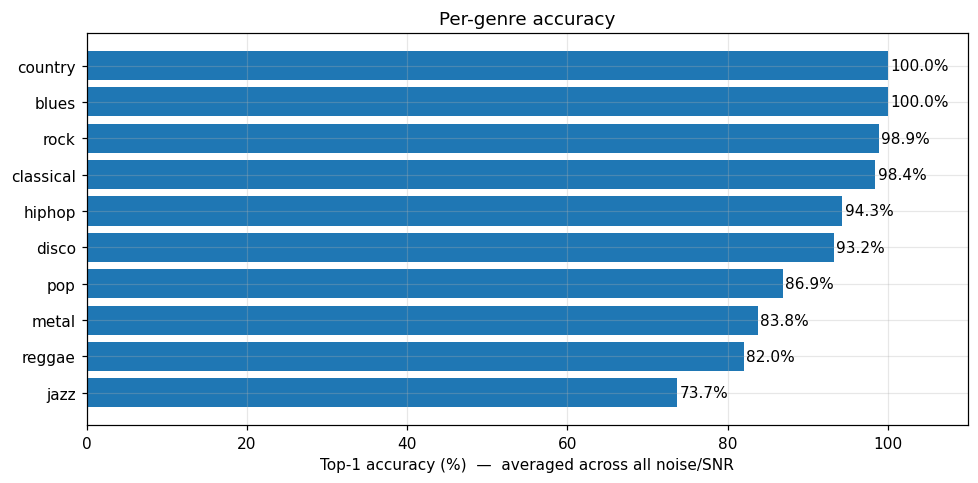

In [32]:
genre_acc = (
    df.groupby("genre")["outcome"]
      .apply(lambda s: (s == "correct").mean() * 100)
      .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(genre_acc.index, genre_acc.values, color="#1f77b4")
for b, v in zip(bars, genre_acc.values):
    ax.text(v + 0.3, b.get_y() + b.get_height() / 2,
            f"{v:.1f}%", va="center")
ax.set_xlabel("Top-1 accuracy (%)  \u2014  averaged across all noise/SNR")
ax.set_title("Per-genre accuracy")
ax.set_xlim(0, max(genre_acc.values) * 1.1)
plt.tight_layout()
plt.show()

### 4a. Per-genre accuracy split by SNR
Same horizontal bar layout as above, but each genre gets one bar per SNR level (averaged across noise types).

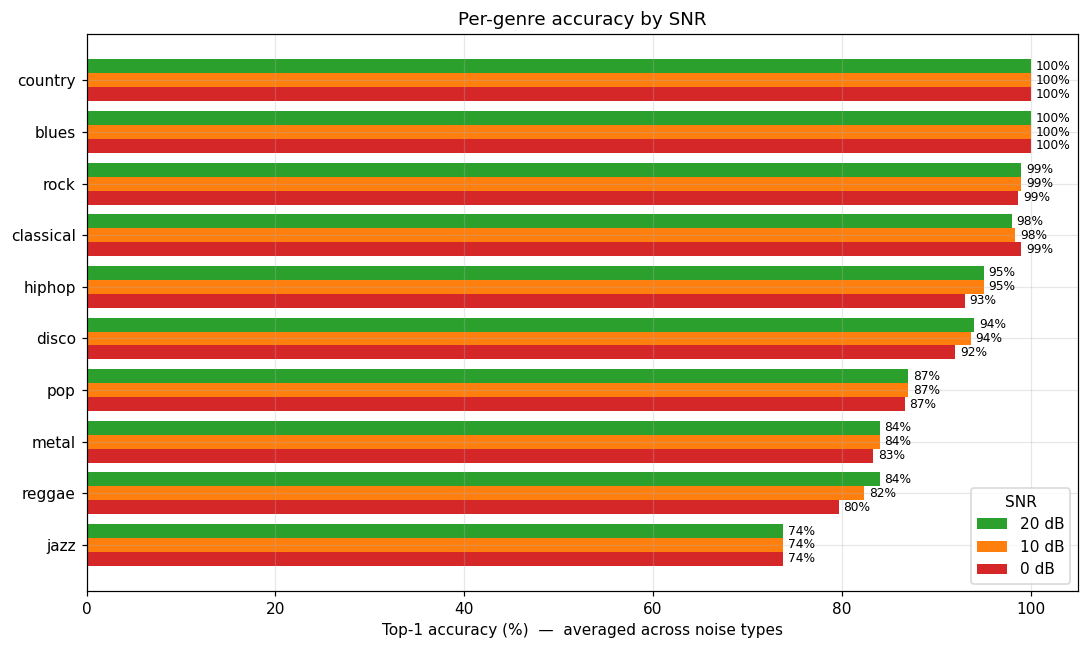

snr_db,0,10,20
genre,,,
jazz,73.7,73.7,73.7
reggae,79.7,82.3,84.0
metal,83.3,84.0,84.0
pop,86.7,87.0,87.0
disco,92.0,93.7,94.0
hiphop,93.0,95.0,95.0
classical,99.0,98.3,98.0
rock,98.7,99.0,99.0
blues,100.0,100.0,100.0


In [33]:
genre_snr_acc = (
    df.groupby(["genre", "snr_db"])["outcome"]
      .apply(lambda s: (s == "correct").mean() * 100)
      .unstack("snr_db")
)

# Match ordering of the previous chart: sort genres by overall accuracy.
genre_order = (
    df.groupby("genre")["outcome"]
      .apply(lambda s: (s == "correct").mean())
      .sort_values()
      .index
)
genre_snr_acc = genre_snr_acc.reindex(genre_order)
snr_levels = sorted(genre_snr_acc.columns, reverse=True)  # cleanest first

snr_colors = {20: "#2ca02c", 10: "#ff7f0e", 0: "#d62728"}

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(genre_snr_acc.index))
bar_height = 0.27
for i, snr in enumerate(snr_levels):
    offset = (i - (len(snr_levels) - 1) / 2) * bar_height
    color = snr_colors.get(snr, plt.cm.RdYlGn(snr / 30))
    vals = genre_snr_acc[snr].values
    bars = ax.barh(y - offset, vals, bar_height, label=f"{snr} dB", color=color)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(v + 0.5, b.get_y() + b.get_height() / 2,
                    f"{v:.0f}%", va="center", fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(genre_snr_acc.index)
ax.set_xlabel("Top-1 accuracy (%)  —  averaged across noise types")
ax.set_title("Per-genre accuracy by SNR")
ax.set_xlim(0, 105)
ax.legend(title="SNR", loc="lower right")
plt.tight_layout()
plt.show()

genre_snr_acc.round(1)

## 5. Genre × SNR heatmaps (one per noise type)
Where does each noise type hurt which genres the most?

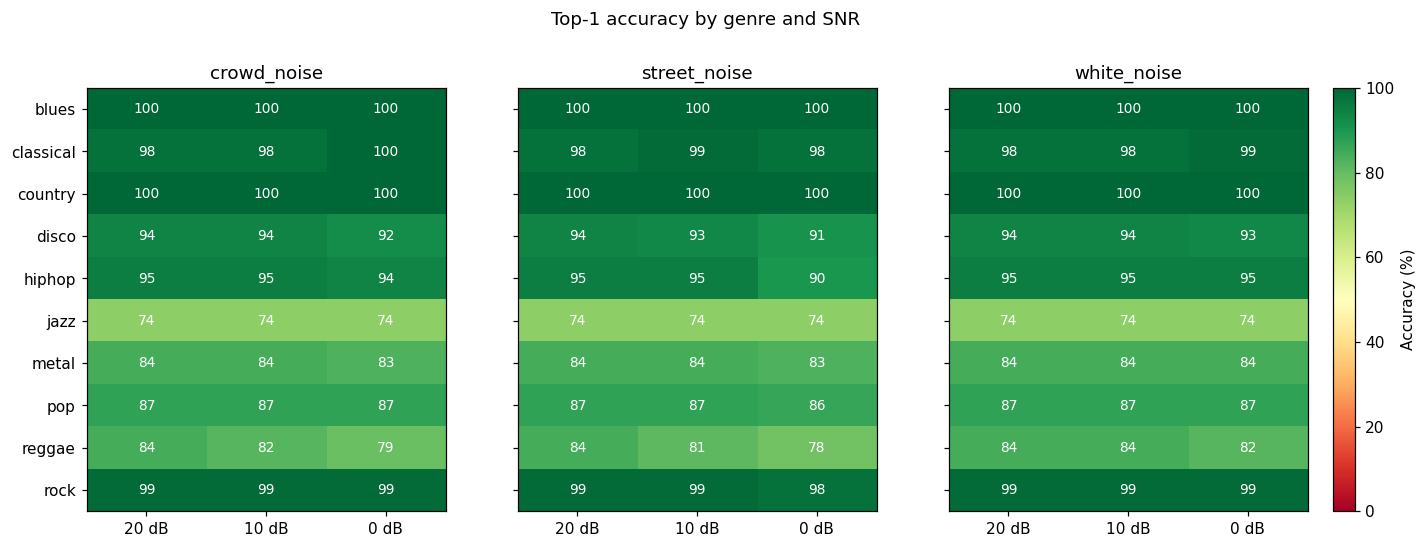

In [34]:
def acc_pivot(sub):
    return sub.pivot_table(
        index="genre", columns="snr_db",
        values="outcome", aggfunc=lambda s: (s == "correct").mean() * 100,
    )

noise_types = sorted(df["noise_type"].unique())
fig, axes = plt.subplots(1, len(noise_types),
                          figsize=(5 * len(noise_types), 5), sharey=True)
if len(noise_types) == 1:
    axes = [axes]

vmax = 100
cmap = "RdYlGn"

for ax, nt in zip(axes, noise_types):
    pivot = acc_pivot(df[df["noise_type"] == nt])
    pivot = pivot.reindex(columns=sorted(pivot.columns, reverse=True))
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, vmin=0, vmax=vmax)
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([f"{c} dB" for c in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(nt)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                        color="black" if 30 < v < 70 else "white", fontsize=9)
    ax.grid(False)
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="Accuracy (%)")
fig.suptitle("Top-1 accuracy by genre and SNR", y=1.02)
plt.show()

## 6. Identification latency
Wall-clock time per `identify_audio()` call. Distribution overall, then by SNR/noise.

/var/folders/wl/l56wm40d1r3d017gmh_0qgbw0000gn/T/ipykernel_8801/3582764344.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=labels, showfliers=False)


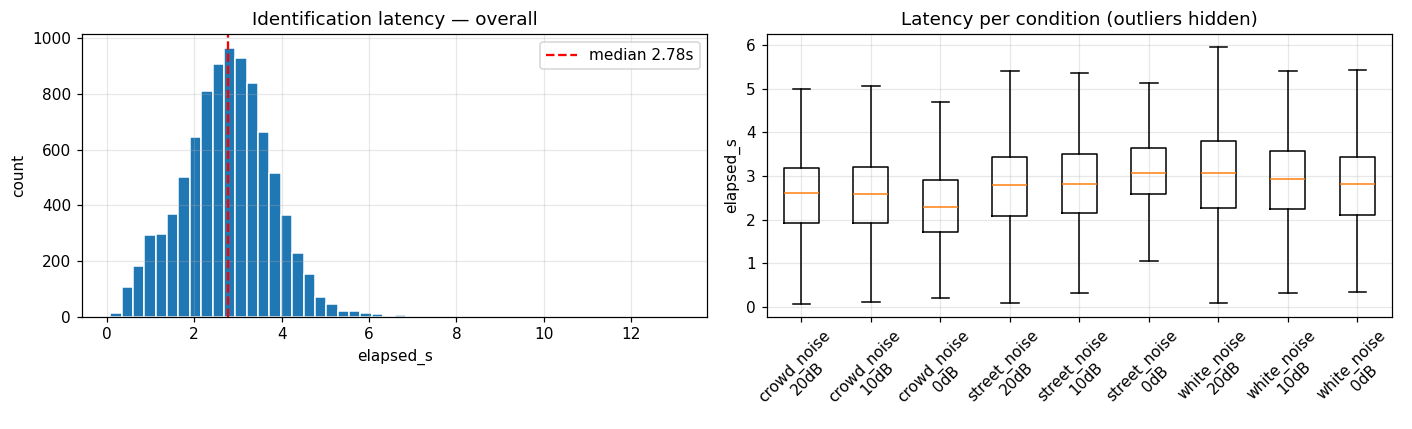

count    8991.000
mean        2.758
std         1.027
min         0.078
25%         2.094
50%         2.781
75%         3.423
max        13.088
Name: elapsed_s, dtype: float64


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) overall histogram
axes[0].hist(df["elapsed_s"], bins=50, color="#1f77b4", edgecolor="white")
med = df["elapsed_s"].median()
axes[0].axvline(med, color="red", linestyle="--", label=f"median {med:.2f}s")
axes[0].set_xlabel("elapsed_s")
axes[0].set_ylabel("count")
axes[0].set_title("Identification latency \u2014 overall")
axes[0].legend()

# (b) box per condition
conditions = sorted(df.groupby(["noise_type", "snr_db"]).groups.keys(),
                     key=lambda k: (k[0], -k[1]))
labels = [f"{nt}\n{snr}dB" for nt, snr in conditions]
data = [df[(df["noise_type"] == nt) & (df["snr_db"] == snr)]["elapsed_s"].values
        for nt, snr in conditions]
axes[1].boxplot(data, labels=labels, showfliers=False)
axes[1].set_ylabel("elapsed_s")
axes[1].set_title("Latency per condition (outliers hidden)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(df["elapsed_s"].describe().round(3))

### 6a. Latency vs outcome
Do rejects take longer than hits? (Often they do — they exhaust the matcher before bailing.)

/var/folders/wl/l56wm40d1r3d017gmh_0qgbw0000gn/T/ipykernel_8801/2618948641.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups, showfliers=False,


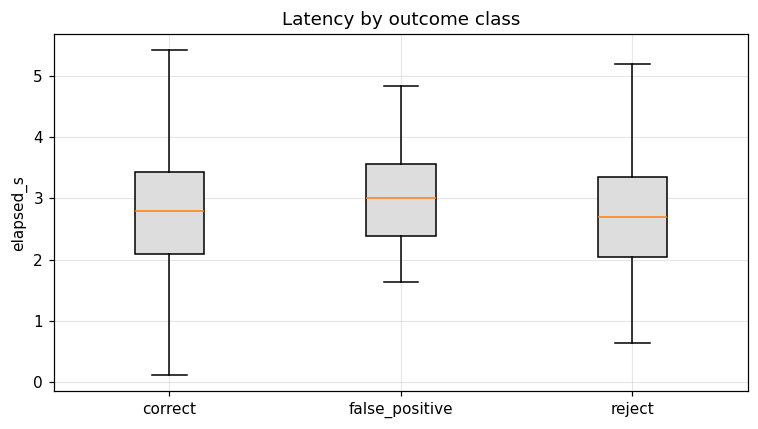

,count,mean,std,min,25%,50%,75%,max
outcome,,,,,,,,
correct,8195.0,2.759,1.026,0.078,2.098,2.786,3.428,13.088
false_positive,80.0,2.993,0.798,1.626,2.392,3.004,3.569,4.829
reject,716.0,2.718,1.049,0.644,2.035,2.689,3.352,8.618


In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
groups = ["correct", "false_positive", "reject"]
data = [df[df["outcome"] == g]["elapsed_s"].values for g in groups]
ax.boxplot(data, labels=groups, showfliers=False,
           patch_artist=True,
           boxprops=dict(facecolor="#dddddd"))
ax.set_ylabel("elapsed_s")
ax.set_title("Latency by outcome class")
plt.tight_layout()
plt.show()

df.groupby("outcome")["elapsed_s"].describe().round(3)

## 7. Confidence / score distributions
Among rows where the matcher *did* identify something, are wrong picks lower-confidence than right ones? If yes, raising `ID_MIN_*` thresholds would convert false positives into rejects.

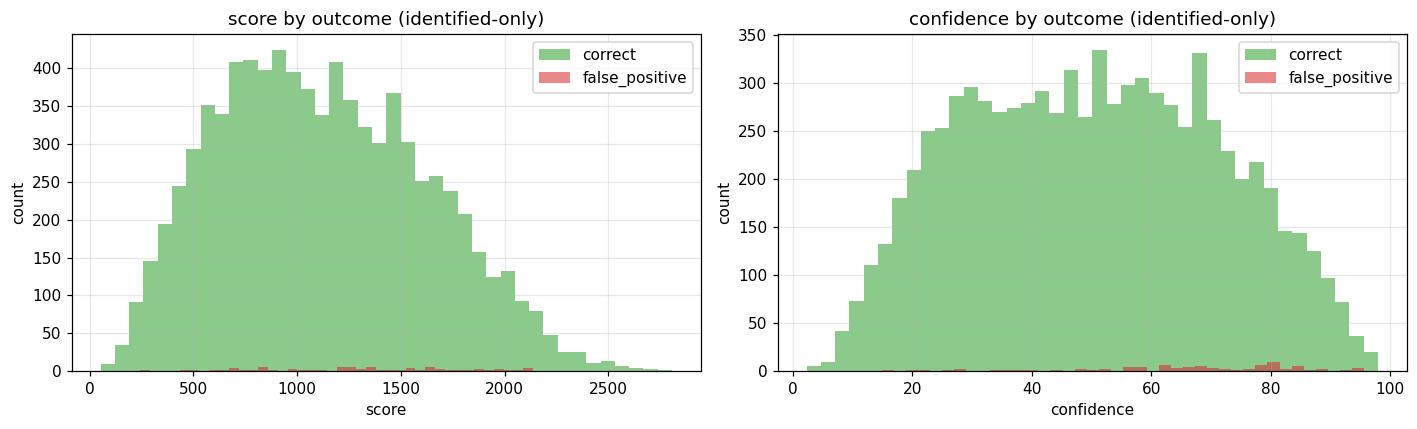

score                                                         \
                 count     mean     std    min    25%     50%     75%     max   
outcome                                                                         
correct         8195.0  1123.24  499.21   53.0  730.5  1083.0  1483.0  2806.0   
false_positive    80.0  1340.56  463.14  244.0  985.5  1341.0  1665.5  2138.0   

               confidence         ...               query_fingerprints  \
                    count   mean  ...    75%    max              count   
outcome                           ...                                    
correct            8195.0  50.17  ...  67.04  97.96             8195.0   
false_positive       80.0  66.26  ...  80.02  95.62               80.0   

                                                                         
                   mean     std     min     25%     50%     75%     max  
outcome                                                                  
correct         2247.78  322.84   957.0  2053.0  2284.0  2481.5  3249.0  
false_positive  2031.99  413.10  1215.0  1832.5  2098.5  2325.5  2689.0  

[2 rows x 24 columns]

In [37]:
ided = df[df["identified"] == "yes"].copy()
ided["score"] = pd.to_numeric(ided["score"], errors="coerce")
ided["confidence"] = pd.to_numeric(ided["confidence"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col in zip(axes, ["score", "confidence"]):
    for label, color in [("correct", "#2ca02c"), ("false_positive", "#d62728")]:
        vals = ided[ided["outcome"] == label][col].dropna()
        if len(vals):
            ax.hist(vals, bins=40, alpha=0.55, label=label, color=color)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.set_title(f"{col} by outcome (identified-only)")
    ax.legend()

plt.tight_layout()
plt.show()

ided.groupby("outcome")[["score", "confidence", "query_fingerprints"]].describe().round(2)

## 8. Genre confusion (when wrong, what genre did it pick?)
Rows of confusion matrix = ground-truth genre, columns = wrongly-picked genre. If wrong picks cluster within-genre, the algorithm is being fooled by stylistic similarity rather than random hash collisions.

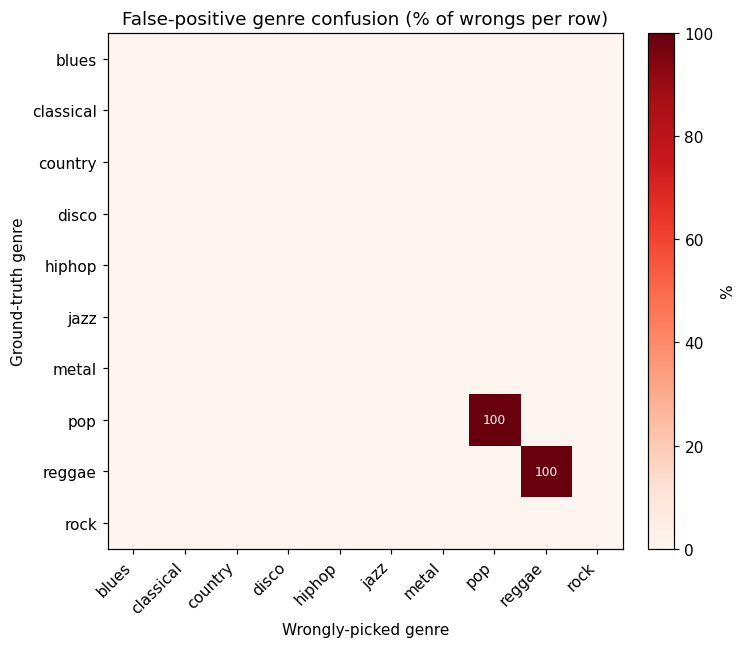

Of 80 false positives, 100.0% landed on the SAME genre as the ground truth.


In [38]:
wrong = df[df["outcome"] == "false_positive"].copy()
if len(wrong) == 0:
    print("No false positives to analyze.")
else:
    confusion = pd.crosstab(
        wrong["genre"], wrong["top_match_genre"], normalize="index"
    ) * 100
    confusion = confusion.reindex(index=sorted(df["genre"].unique()),
                                    columns=sorted(df["genre"].unique())).fillna(0)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(confusion.values, cmap="Reds", vmin=0, vmax=confusion.values.max())
    ax.set_xticks(np.arange(len(confusion.columns)))
    ax.set_xticklabels(confusion.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(confusion.index)))
    ax.set_yticklabels(confusion.index)
    ax.set_xlabel("Wrongly-picked genre")
    ax.set_ylabel("Ground-truth genre")
    ax.set_title("False-positive genre confusion (% of wrongs per row)")
    for i in range(confusion.shape[0]):
        for j in range(confusion.shape[1]):
            v = confusion.values[i, j]
            if v >= 1:
                ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                        color="black" if v < confusion.values.max() * 0.55 else "white",
                        fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="%")
    ax.grid(False)
    plt.tight_layout()
    plt.show()

    same_genre = (wrong["genre"] == wrong["top_match_genre"]).mean() * 100
    print(f"Of {len(wrong):,} false positives, "
          f"{same_genre:.1f}% landed on the SAME genre as the ground truth.")

## 9. Summary table for the write-up
One row per (noise, SNR) condition with all four key metrics.

In [39]:
summary = (
    df.groupby(["noise_type", "snr_db"])
      .apply(lambda g: pd.Series({
          "n": len(g),
          "accuracy_%": (g["outcome"] == "correct").mean() * 100,
          "false_positive_%": (g["outcome"] == "false_positive").mean() * 100,
          "reject_%": (g["outcome"] == "reject").mean() * 100,
          "median_elapsed_s": g["elapsed_s"].median(),
      }))
      .round(2)
      .sort_index()
)
summary

/var/folders/wl/l56wm40d1r3d017gmh_0qgbw0000gn/T/ipykernel_8801/3919413780.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


n  accuracy_%  false_positive_%  reject_%  \
noise_type   snr_db                                                  
crowd_noise  0       999.0       90.79               0.7      8.51   
             10      999.0       91.29               0.9      7.81   
             20      999.0       91.49               1.1      7.41   
street_noise 0       999.0       89.79               0.5      9.71   
             10      999.0       91.19               0.8      8.01   
             20      999.0       91.49               0.9      7.61   
white_noise  0       999.0       91.29               0.9      7.81   
             10      999.0       91.49               1.0      7.51   
             20      999.0       91.49               1.2      7.31   

                     median_elapsed_s  
noise_type   snr_db                    
crowd_noise  0                   2.29  
             10                  2.59  
             20                  2.60  
street_noise 0                   3.08  
             10                  2.83  
             20                  2.80  
white_noise  0                   2.82  
             10                  2.93  
             20                  3.06